In [36]:
# %matplotlib widget
import os
import logging
from glob import glob
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from matplotlib.backends.backend_pdf import PdfPages

from astropy.io import fits
from astropy.time import Time
from astropy.stats import sigma_clipped_stats

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy import signal

from rich.table import Table
from rich.console import Console

In [2]:
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'axes.labelpad': 10,
    'axes.linewidth': 1.2,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.fontsize': 12,
})

In [3]:
# instead of print statements, I am using logger, to classify the messages into INFO, WARNING, ERROR. 
def get_logger(log_file: str) -> logging.Logger:
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    
    formatter = logging.Formatter("[%(levelname)s at %(asctime)s] — %(message)s")
    
    fh = logging.FileHandler(log_file)
    fh.setFormatter(formatter)
    logger.addHandler(fh)
    
    sh = logging.StreamHandler()  # prints to notebook
    sh.setFormatter(formatter)
    logger.addHandler(sh)
    
    return logger, fh

# I will use this function to now open a log file and write all the messages to it, while also printing to the notebook.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
logger, fh = get_logger(f"logs/run_{timestamp}.log")
logger.info("Logger initialized successfully")

[INFO at 2026-06-22 10:45:20,591] — Logger initialized successfully


I am defining a hardcoded path where all my arcs live. All files that are used for the analysis can be found in: https://drive.google.com/drive/folders/19h8VGkpD-v3I4oyzC0lOfDhMXMJpQ2yO?usp=sharing

In [4]:
pre_maintenance_dir  = "/Users/ani/Downloads/pre_maintainance/spectroscopy"
post_maintenance_dir = "/Users/ani/Downloads/post_maintainance/spectroscopy"

In [5]:
# Search for all downloaded FITS files recursively
def get_all_fits_files(directory: str) -> list:
    """
    Recursively searches for all FITS files in the given directory and its subdirectories.
    """
    if not os.path.exists(directory):
        logger.error(f"Directory does not exist: {directory}")
        return []
    return glob(os.path.join(directory, "**/*.fits*"), recursive=True)




# a function to filter out bad files based on some criteria, such as file size or header keywords.
# filter the arc files
def filter_fits_files(file_list):
    """
    Removes:
    - ARC files from 'triplespec' instrument
    - ARC files which are standard AEON night calibrations. they have the header key OBJECT == 'ARC'

    Keeps:
    - ARC files that are taken before and after the science exposures, which are the ones relevant for this study.
    
    Inputs:
        file_list: list of .fits file paths
    Outputs:
        good_files: list of filtered file paths
    """
    good_files = []
    
    for file in file_list:
        logger.info(f"Processing file: {file}")
        try:
            with fits.open(file) as hdul:
                header = hdul[1].header
                
                instrume = header.get("INSTRUME", "").lower()
                object_val = header.get("OBJECT", "").strip().upper()
                
                # Not considering arcs from triplespec, as they are not relevant for this study.
                if instrume == "triplespec":
                    logger.warning(f"Skipping {file} — INSTRUME: {header['INSTRUME']}")
                    continue
                
                # I am skipping arc files that are a part of the standard AEON night calibrations. They have a particular header keyword that identifies them as arcs fromt the standard AEON calibrations. For this study, we don't need them as we are mostly instrested in arcs taken before and after the science exposures. 
                if object_val == "ARC":
                    logger.warning(f"Skipping {file} — OBJECT: {header['OBJECT']}")
                    continue
                
                good_files.append(file)

        #just in case, if any file is corrupt.  
        except Exception as e:
            logger.error(f"Skipping {file} — could not read: {e}")
            continue
    
    if len(good_files) == 0:
        logger.warning("No good files found after filtering.")
    else:
        logger.info(f"Found {len(good_files)} good files after filtering.")
    return good_files

In [6]:
# Now I will get all the fits files from both pre and post maintenance directories, and then filter them using the above function.
pre_maintenance_files  = get_all_fits_files(pre_maintenance_dir)
post_maintenance_files = get_all_fits_files(post_maintenance_dir)


good_pre_files  = filter_fits_files(pre_maintenance_files) #arc files that are relevant for this study, taken before the maintenance
good_post_files = filter_fits_files(post_maintenance_files) #arc files that are relevant for this study, taken after the maintenance

[INFO at 2026-06-22 10:45:28,513] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0252_Calibration-Star_08-12-2025_comp.fits.fz
[INFO at 2026-06-22 10:45:28,529] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0249_Calibration-Star_08-01-2026_comp.fits.fz
[INFO at 2026-06-22 10:45:28,551] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0199_ZTF26aaffxis_17-02-2026_comp.fits.fz
[INFO at 2026-06-22 10:45:28,572] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0252_Calibration-Star_30-12-2025_comp.fits.fz
[INFO at 2026-06-22 10:45:28,578] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0252_Calibration-Star_03-01-2026_comp.fits.fz
[INFO at 2026-06-22 10:45:28,584] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/0249_Calibration-Star_03-12-2025_comp.fits.fz
[INFO at 2026-06-22 10:45:28,589] — Processing file: /Users/ani/Downloads/pre_maintainance/spectroscopy/

In [7]:
logger.info(f'Keeping {len(good_pre_files)}/{len(pre_maintenance_files)} pre-maintenance files and {len(good_post_files)}/{len(post_maintenance_files)} post-maintenance files for analysis.')

[INFO at 2026-06-22 10:45:30,476] — Keeping 210/210 pre-maintenance files and 171/171 post-maintenance files for analysis.


In [8]:
def read_fits_file(file: str) -> tuple:
    """
    Reads a FITS file and returns a merged header and data dictionary.
    - header: merged across all HDUs (later HDUs overwrite earlier ones on duplicate keys)
    - data: dict of {hdu_index: data_array} for all HDUs
    """
    with fits.open(file) as hdul:
        header = hdul[0].header
        for i in range(1, len(hdul)):
            header.update(hdul[i].header)
        data = {i: hdul[i].data for i in range(len(hdul))}
    return header, data

    
def find_lamp_type(header: dict) -> str:

    # From the file headers, these are all the lamps available.
    lamp_mapping = {
        "LAMP_HGA": "HgAr",
        "LAMP_NE": "Ne",
        "LAMP_AR": "Ar",
        "LAMP_FE": "Fe",
        "LAMP_CU": "Cu",
        "LAMP_QUA": "Quartz",
    }

    # the heaker key hwere the value is True, is the lamp turned on. So I am considering only those lamps that are turned on, and making a tuple of their names. This step is added to identify what was the lamp that was used for the arc.
    Lamps = tuple(
        name 
        for kw, name in lamp_mapping.items() 
        if header.get(kw) in [True, "TRUE", "T"]
    )

    # if multple lamps are on, join them with a +, for example: HgAr+Ne
    lamp_str = "+".join(Lamps) if Lamps else "Unknown"

    return lamp_str

In [9]:
def build_arc_groups(good_files: list, 
                    valid_gratings: tuple = ("400_M1", "400_M2")
                    ) -> tuple[list[dict], defaultdict]:
    """
    Reads metadata from a list of arc FITS files and groups them by date, object, and grating.

    Inputs:
        good_files: list of file paths (output of filter_fits_files)
        valid_gratings: tuple of grating names to keep
    Outputs:
        metadata: list of metadata dicts, one per file
        groups: nested defaultdict grouped as groups[date][object][grating] -> list of entries
    """

    # creating a list of metadata dicts, one per file, that contains all the relevant information we need for our analysis, such as date, object, grating, lamp type.
    metadata = []
    for good_file in good_files:
        header, data = read_fits_file(good_file)
        lamp = find_lamp_type(header)
        filename = os.path.basename(good_file)
        file_path = os.path.dirname(good_file)

        metadata.append({
            "filename": filename,
            "file_path": file_path,
            "date": header['DATE'],
            "obs_datetime": header["DATE-OBS"],
            "grating": header['WAVMODE'],
            "lamps": lamp,
            "object": header.get("OBJECT", "N/A"),
        })

    # Now, with all the existing metadata, I am grouping the files in the following order: data -> object -> grating. This will give me a nested disctionary. The values will be lists of metadata entries that correspond to each combination of date, object, and grating. This grouping will allow me to easily access and analyze the arcs based on these criteria, which is important for understanding any patterns or trends in the data related to the mask slip issue.
    groups = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for entry in metadata:
        grating = entry["grating"]
        if grating in valid_gratings:
            logger.info(f"Grouping file: {entry['filename']} — Date: {entry['date']}, OBJECT: {entry['object']}, Grating: {grating}")
            groups[entry["date"]][entry["object"]][grating].append(entry)
        else:
            logger.warning(f"Skipping file with unexpected grating: {entry['filename']} — Grating: {grating}")

    return metadata, groups

In [10]:
# Now I will build the arc groups for both pre and post maintenance files, using the above function. This will give me a structured way to access the arcs based on their date, object, and grating, which will be useful for my analysis of the mask slip issue.
arcs_metadata_pre, groups_pre   = build_arc_groups(good_pre_files)
arcs_metadata_post, groups_post = build_arc_groups(good_post_files)

[WARNING at 2026-06-22 10:45:39,246] — Skipping file with unexpected grating: 0252_Calibration-Star_08-12-2025_comp.fits.fz — Grating: 2100_5000A
[INFO at 2026-06-22 10:45:39,247] — Grouping file: 0249_Calibration-Star_08-01-2026_comp.fits.fz — Date: 2026-01-08, OBJECT: HR1996, Grating: 400_M2
[INFO at 2026-06-22 10:45:39,248] — Grouping file: 0199_ZTF26aaffxis_17-02-2026_comp.fits.fz — Date: 2026-02-17, OBJECT: ZTF26aaffxis, Grating: 400_M1
[WARNING at 2026-06-22 10:45:39,248] — Skipping file with unexpected grating: 0252_Calibration-Star_30-12-2025_comp.fits.fz — Grating: 2100_5000A
[WARNING at 2026-06-22 10:45:39,249] — Skipping file with unexpected grating: 0252_Calibration-Star_03-01-2026_comp.fits.fz — Grating: 2100_5000A
[INFO at 2026-06-22 10:45:39,249] — Grouping file: 0249_Calibration-Star_03-12-2025_comp.fits.fz — Date: 2025-12-03, OBJECT: HR9087, Grating: 400_M2
[INFO at 2026-06-22 10:45:39,249] — Grouping file: 0260_ZTF25acfybcc_17-12-2025_comp.fits.fz — Date: 2025-12-17, 

In [11]:
table = Table(title="Arc Group Summary")
table.add_column("Maintenance Status", style="cyan")
table.add_column("Number of Groups",   style="magenta", justify="right")
table.add_column("Median Files/Group", style="green",   justify="right")

for groups, label in [(groups_pre, "Pre-Maintenance"), (groups_post, "Post-Maintenance")]:
    group_sizes = []
    for date in groups:
        for obj in groups[date]:
            for grating in groups[date][obj]:
                group_sizes.append(len(groups[date][obj][grating]))

    n_groups     = len(group_sizes)
    median_files = np.median(group_sizes) if group_sizes else 0

    table.add_row(label, str(n_groups), f"{median_files:.1f}")

Console().print(table)

                      Arc Group Summary                       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ Number of Groups ┃ Median Files/Group ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │               78 │                1.5 │
│ Post-Maintenance   │               51 │                2.0 │
└────────────────────┴──────────────────┴────────────────────┘

In [12]:
def build_grouped_arc_files(groups: defaultdict, standard_stars: set) -> list[dict]:
    """
    Flattens a nested arc group defaultdict into a sorted, enriched list of valid arc groups.

    Removes:
    - Groups where the object is a known standard star
    - Groups with fewer than 2 arc files

    Inputs:
        groups: nested defaultdict grouped as groups[date][object][grating] -> list of entries
        standard_stars: set of object names to exclude (e.g. known spectrophotometric standards)
    Outputs:
        grouped_arc_files: flat list of dicts, one per valid group, with sorted filenames,
                           file paths, datetimes, and delta times
    """
    grouped_arc_files = []

    for date in groups.keys():
        for obj in groups[date].keys():
            for grating in groups[date][obj].keys():
                arc_files = groups[date][obj][grating]
                count = len(arc_files)
                sorted_files = sorted(arc_files, key=lambda x: x["obs_datetime"])

                if "Calibration-Star" in arc_files:
                    logger.warning(f"Skipping Calibration-Star group — Date: {date}, OBJECT: {obj}, Grating: {grating}")
                    continue

                if obj in standard_stars:
                    logger.warning(f"Skipping standard star — Date: {date}, OBJECT: {obj}, Grating: {grating}")
                    continue

                if count < 2:
                    logger.warning(f"Not enough files to analyze — Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")
                    continue

                previous_file_datetime = None
                logger.info("-" * 50)
                logger.info(f"Date: {date}, OBJECT: {obj}, Grating: {grating}, Count: {count}")

                delta_file_datetime_seconds_all = []
                for arc_file in sorted_files:
                    filename = arc_file["filename"]
                    current_file_datetime = Time(arc_file["obs_datetime"]).to_datetime()

                    if previous_file_datetime is None:
                        delta_file_datetime_seconds = 0
                    else:
                        delta_file_datetime_seconds = (current_file_datetime - previous_file_datetime).total_seconds()

                    logger.info(f"  - {filename}, dt = {delta_file_datetime_seconds} seconds")
                    delta_file_datetime_seconds_all.append(delta_file_datetime_seconds)

                    previous_file_datetime = current_file_datetime

                grouped_arc_files.append({
                    "date": date,
                    "object": obj,
                    "grating": grating,
                    "lamps": arc_files[0]["lamps"],
                    "arc_files": [arc_file["filename"] for arc_file in sorted_files],
                    "file_paths": [arc_file["file_path"] for arc_file in sorted_files],
                    "datetimes": [arc_file["obs_datetime"] for arc_file in sorted_files],
                    "delta_time_seconds": delta_file_datetime_seconds_all,
                })

    return grouped_arc_files

In [13]:
standard_stars = {"HR9087", "HR1996", "LTT3218", "HD49798"}

grouped_arc_files_pre  = build_grouped_arc_files(groups_pre,  standard_stars)
grouped_arc_files_post = build_grouped_arc_files(groups_post, standard_stars)

[WARNING at 2026-06-22 10:45:46,275] — Skipping standard star — Date: 2026-01-08, OBJECT: HR1996, Grating: 400_M2
[WARNING at 2026-06-22 10:45:46,275] — Skipping standard star — Date: 2026-01-08, OBJECT: HR1996, Grating: 400_M1
[INFO at 2026-06-22 10:45:46,275] — --------------------------------------------------
[INFO at 2026-06-22 10:45:46,276] — Date: 2026-01-08, OBJECT: 2025ahoe, Grating: 400_M1, Count: 3
[INFO at 2026-06-22 10:45:46,278] —   - 0288_2025ahoe_08-01-2026_comp.fits.fz, dt = 0 seconds
[INFO at 2026-06-22 10:45:46,278] —   - 0289_2025ahoe_08-01-2026_comp.fits.fz, dt = 11.493 seconds
[INFO at 2026-06-22 10:45:46,279] —   - 0290_2025ahoe_08-01-2026_comp.fits.fz, dt = 11.397 seconds
[INFO at 2026-06-22 10:45:46,279] — --------------------------------------------------
[INFO at 2026-06-22 10:45:46,279] — Date: 2026-02-17, OBJECT: ZTF26aaffxis, Grating: 400_M1, Count: 6
[INFO at 2026-06-22 10:45:46,280] —   - 0197_ZTF26aaffxis_17-02-2026_comp.fits.fz, dt = 0 seconds
[INFO at

In [14]:
table = Table(title="Arc Group Summary")
table.add_column("Maintenance Status", style="cyan")
table.add_column("Number of Groups",   style="magenta", justify="right")
table.add_column("Median Files/Group", style="green",   justify="right")

for grouped_arc_files, label in [(grouped_arc_files_pre, "Pre-Maintenance"), (grouped_arc_files_post, "Post-Maintenance")]:
    group_sizes  = [len(group["arc_files"]) for group in grouped_arc_files]
    n_groups     = len(group_sizes)
    median_files = np.median(group_sizes) if group_sizes else 0

    table.add_row(label, str(n_groups), f"{median_files:.1f}")

Console().print(table)

                      Arc Group Summary                       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Maintenance Status ┃ Number of Groups ┃ Median Files/Group ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Pre-Maintenance    │               35 │                3.0 │
│ Post-Maintenance   │               23 │                6.0 │
└────────────────────┴──────────────────┴────────────────────┘

In [15]:
def calculate_cross_correlation_shifts(grouped_arc_files: list[dict]) -> None:
    """
    Calculates cross-correlation shifts for all arc files in each group,
    relative to the first file in the group.

    Updates each group dict in-place with:
        - dx: list of integer pixel shifts relative to file 0
        - confidence_scores: list of normalized cross-correlation scores (0.0 to 1.0)

    Inputs:
        grouped_arc_files: list of group dicts (output of build_grouped_arc_files)
    Outputs:
        None — modifies grouped_arc_files in-place
    """
    logger.info(f"Starting cross-correlation shift calculation for {len(grouped_arc_files)} groups...")

    for group in grouped_arc_files:
        files = [
            os.path.join(group["file_paths"][i], group["arc_files"][i])
            for i in range(len(group["arc_files"]))
        ]

        if not files:
            group["dx"] = []
            group["confidence_scores"] = []
            continue

        # Establish the reference spectrum from file 0
        reference_file = files[0]
        try:
            _, data = read_fits_file(reference_file)
            one_d_spec_reference = np.sum(data[1], axis=0).astype(np.float64)
        except Exception as e:
            logger.error(f"Failed to read reference file {reference_file}: {e}")
            group["dx"] = [np.nan] * len(files)
            group["confidence_scores"] = [np.nan] * len(files)
            continue

        relative_shifts  = []
        confidence_scores = []

        for current_file in files[1:]:  # start from file 1, since file 0 is the reference
            try:
                _, data = read_fits_file(current_file)
                current_spectrum = np.sum(data[1], axis=0).astype(np.float64)

                # Cross-correlate against the reference spectrum
                correlation = signal.correlate(current_spectrum, one_d_spec_reference, mode='full')
                lags        = signal.correlation_lags(len(current_spectrum), len(one_d_spec_reference), mode='full')

                best_idx   = np.argmax(correlation)
                shift_pixels = lags[best_idx]

                # Normalized confidence score (0.0 to 1.0)
                norm_factor      = np.sqrt(np.sum(current_spectrum**2) * np.sum(one_d_spec_reference**2))
                confidence_score = correlation[best_idx] / norm_factor

                relative_shifts.append(shift_pixels)
                confidence_scores.append(confidence_score)

                logger.info(f"  {os.path.basename(current_file)} — Shift: {shift_pixels} px | Confidence: {confidence_score:.4f}")

            except Exception as e:
                logger.error(f"Failed to process file {current_file}: {e}")
                relative_shifts.append(np.nan)
                confidence_scores.append(np.nan)

        group["dx"] = relative_shifts
        group["confidence_scores"] = confidence_scores

        logger.info(
            f"Processed Date: {group['date']} | Obj: {group['object']} | Grating: {group['grating']} "
            f"— Shifts: {relative_shifts}"
        )

    logger.info("Finished calculating all dx shifts.")

In [16]:
calculate_cross_correlation_shifts(grouped_arc_files_pre)
calculate_cross_correlation_shifts(grouped_arc_files_post)

[INFO at 2026-06-22 10:45:46,628] — Starting cross-correlation shift calculation for 35 groups...
[INFO at 2026-06-22 10:45:46,760] —   0289_2025ahoe_08-01-2026_comp.fits.fz — Shift: 0 px | Confidence: 0.9946
[INFO at 2026-06-22 10:45:46,799] —   0290_2025ahoe_08-01-2026_comp.fits.fz — Shift: 0 px | Confidence: 0.9807
[INFO at 2026-06-22 10:45:46,800] — Processed Date: 2026-01-08 | Obj: 2025ahoe | Grating: 400_M1 — Shifts: [np.int64(0), np.int64(0)]
[INFO at 2026-06-22 10:45:46,864] —   0198_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: 0 px | Confidence: 1.0000
[INFO at 2026-06-22 10:45:46,900] —   0199_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: 0 px | Confidence: 0.9907
[INFO at 2026-06-22 10:45:46,934] —   0203_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: -9 px | Confidence: 0.4684
[INFO at 2026-06-22 10:45:46,968] —   0204_ZTF26aaffxis_17-02-2026_comp.fits.fz — Shift: -9 px | Confidence: 0.6101
[INFO at 2026-06-22 10:45:47,000] —   0205_ZTF26aaffxis_17-02-2026_comp.fits.fz — Sh

In [17]:
def print_dx_matrix(grouped_arc_files: list[dict], title: str) -> None:
    """
    Prints the dx shifts for all groups as a matrix, one group per row.
    Non-zero shifts are highlighted in red.

    Inputs:
        grouped_arc_files: list of group dicts (output of calculate_cross_correlation_shifts)
        title: table title (e.g. 'Pre-Maintenance dx Matrix')
    """
    max_files = max(len(group["dx"]) for group in grouped_arc_files)

    table = Table(title=title)
    table.add_column("Date",    style="cyan",    no_wrap=True)
    table.add_column("Object",  style="magenta", no_wrap=True)
    table.add_column("Grating", style="green",   no_wrap=True)

    for i in range(max_files):
        table.add_column(f"dx[{i}]", justify="right")

    for group in sorted(grouped_arc_files, key=lambda x: x["date"]):
        dx = group["dx"]
        row = [
            group["date"],
            group["object"],
            group["grating"],
        ]
        for i in range(max_files):
            if i < len(dx):
                val = dx[i]
                if np.isnan(val):
                    row.append("NaN")
                elif val != 0:
                    row.append(f"[red]{val:.1f}[/red]")
                else:
                    row.append(f"{val:.1f}")
            else:
                row.append("-")

        table.add_row(*row)

    Console().print(table)

In [18]:
print_dx_matrix(grouped_arc_files_pre,  "Pre-Maintenance dx Matrix")

                                        Pre-Maintenance dx Matrix                                         
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ Date       ┃ Object          ┃ Grating ┃ dx[0] ┃ dx[1] ┃ dx[2] ┃ dx[3] ┃ dx[4] ┃ dx[5] ┃ dx[6] ┃ dx[7] ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 2025-12-03 │ ZTF25acbjqvq    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF25abxvhmk    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF18acecugr    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-03 │ ZTF25abwkieo    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-08 │ Fortinbras-host │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-12 │ ZTF25accmopr    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-12 │ ZTF25acfyeke    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-12 │ ZTF25acfyjrh    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25acfybcc    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ 2023fhn-host    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgyzdb    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25achwuhy    │ 400_M1  │   0.0 │   0.0 │   3.0 │   3.0 │   3.0 │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgopcs    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-17 │ ZTF25acgwohc    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-30 │ ZTF25aciemqo    │ 400_M1  │  -6.0 │  -6.0 │     - │     - │     - │     - │     - │     - │
│ 2025-12-30 │ ZTF25achxgfw    │ 400_M1  │   0.0 │   0.0 │   8.0 │   8.0 │   8.0 │     - │     - │     - │
│ 2025-12-30 │ ZTF18aafhmpq    │ 400_M1  │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2025-12-30 │ ZTF25acjfaoq    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-03 │ ZTF18acecugr    │ 400_M2  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-03 │ ZTF18acecugr    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-04 │ ZTF25achogfs    │ 400_M1  │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2026-01-04 │ ZTF25acjbekr    │ 400_M1  │   0.0 │   0.0 │   6.0 │   6.0 │   6.0 │     - │     - │     - │
│ 2026-01-07 │ ZTF25acgorke    │ 400_M1  │   0.0 │   0.0 │   1.0 │   1.0 │   1.0 │     - │     - │     - │
│ 2026-01-08 │ 2025ahoe        │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-19 │ ZTF26aaayaic    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-01-19 │ ZTF26aabpzxh    │ 400_M1  │   0.0 │   0.0 │   4.0 │   4.0 │   4.0 │     - │     - │     - │
│ 2026-01-27 │ ZTF26aabpzxh    │ 400_M1  │   0.0 │   0.0 │   0.0 │   0.0 │   0.0 │   6.0 │   6.0 │   6.0 │
│ 2026-02-11 │ ZTF26aaecpsp    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffxis    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffpvx    │ 400_M2  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-11 │ ZTF26aaffpvx    │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-17 │ ZTF26aaffxis    │ 400_M1  │   0.0 │   0.0 │  -9.0 │  -9.0 │  -9.0 │     - │     - │     - │
│ 2026-02-23 │ ASKAPJ0408-3250 │ 400_M2  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-02-24 │ ZTF23aacnjqh    │ 400_M2  

In [19]:
print_dx_matrix(grouped_arc_files_post, "Post-Maintenance dx Matrix")

                                         Post-Maintenance dx Matrix                                         
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃ Date       ┃ Object            ┃ Grating ┃ dx[0] ┃ dx[1] ┃ dx[2] ┃ dx[3] ┃ dx[4] ┃ dx[5] ┃ dx[6] ┃ dx[7] ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 2026-04-22 │ 43977565387744629 │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-04-22 │ ZTF26aaonmha      │ 400_M1  │   0.0 │   0.0 │   0.0 │   0.0 │   0.0 │   6.0 │   6.0 │   6.0 │
│ 2026-04-22 │ ZTF26aanefqu      │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-04-26 │ ZTF26aapoypz      │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-04-26 │ ZTF26aasmxig      │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-04-30 │ ZTF26aasnlpp      │ 400_M1  │   0.0 │   0.0 │ 802.0 │   4.0 │   4.0 │     - │     - │     - │
│ 2026-04-30 │ ZTF26aaonmha      │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-05-08 │ ZTF26aaudbym      │ 400_M1  │   0.0 │   0.0 │   3.0 │   3.0 │   3.0 │     - │     - │     - │
│ 2026-05-09 │ ZTF26aauuvgc      │ 400_M1  │   0.0 │   0.0 │   5.0 │   5.0 │   5.0 │     - │     - │     - │
│ 2026-05-09 │ ZTF26aaudbym      │ 400_M1  │   0.0 │   0.0 │   2.0 │   2.0 │   2.0 │     - │     - │     - │
│ 2026-05-12 │ ZTF26aauxgoe      │ 400_M2  │   0.0 │   0.0 │   3.0 │   3.0 │   0.0 │     - │     - │     - │
│ 2026-05-12 │ ZTF26aauuvgc      │ 400_M2  │   0.0 │   0.0 │   7.0 │   7.0 │   7.0 │     - │     - │     - │
│ 2026-05-16 │ ZTF26aauvalc      │ 400_M1  │   0.0 │   0.0 │   9.0 │   9.0 │   9.0 │     - │     - │     - │
│ 2026-05-20 │ ASKAP14517689     │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-05-26 │ ZTF26aaxhvtq      │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-06-06 │ LTT9239           │ 400_M1  │  23.0 │     - │     - │     - │     - │     - │     - │     - │
│ 2026-06-07 │ HD60753           │ 400_M1  │  22.0 │     - │     - │     - │     - │     - │     - │     - │
│ 2026-06-08 │ LB769             │ 400_M1  │   0.0 │   0.0 │ -10.0 │ -10.0 │ -10.0 │     - │     - │     - │
│ 2026-06-08 │ LB769             │ 400_M2  │   0.0 │   0.0 │   0.0 │   0.0 │     - │     - │     - │     - │
│ 2026-06-08 │ ZTF26aazexdl      │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-06-14 │ ZTF26aaxnixn      │ 400_M1  │   0.0 │   0.0 │   7.0 │   7.0 │   6.0 │     - │     - │     - │
│ 2026-06-14 │ ZTF22aaqqapy      │ 400_M1  │   0.0 │   0.0 │     - │     - │     - │     - │     - │     - │
│ 2026-06-14 │ ZTF26aazjcyz      │ 400_M1  │   0.0 │  -3.0 │   2.0 │   2.0 │   2.0 │     - │     - │     - │
└────────────┴───────────────────┴─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘

In [20]:
CONF_THRESHOLD = 0.8
DX_MAX         = 20
SLIP_THRESHOLD = 2

def compute_summary(grouped_arc_files):
    total       = len(grouped_arc_files)
    slip_count  = 0
    slip_mags   = []

    for g in grouped_arc_files:
        dx_clean = [
            g["dx"][i] for i in range(len(g["dx"]))
            if not np.isnan(g["dx"][i])
            and abs(g["dx"][i]) < DX_MAX
            and g["confidence_scores"][i] >= CONF_THRESHOLD
        ]
        if len(dx_clean) < 2:
            continue
        dx_range = max(dx_clean) - min(dx_clean)
        if dx_range >= SLIP_THRESHOLD:
            slip_count += 1
            slip_mags.append(dx_range)

    slip_pct    = 100 * slip_count / total if total > 0 else 0
    median_slip = np.median(slip_mags) if slip_mags else 0
    max_slip    = max(slip_mags)       if slip_mags else 0

    return total, slip_count, slip_pct, median_slip, max_slip


table = Table(title="Arc Slip Summary (confidence ≥ 0.8, |dx| < 20, slip = dx range ≥ 2 px)")
table.add_column("Metric",                  style="cyan")
table.add_column("Pre-Maintenance",         style="magenta", justify="right")
table.add_column("Post-Maintenance",        style="green",   justify="right")

rows = [
    ("Total groups",              "{total}",                          ),
    ("Groups with slip detected", "{slip_count} ({slip_pct:.0f}%)",  ),
    ("Median slip magnitude (px)","[red]{median_slip:.1f}[/red]"     ),
    ("Max slip magnitude (px)",   "[red]{max_slip:.1f}[/red]"        ),
]

pre_stats  = compute_summary(grouped_arc_files_pre)
post_stats = compute_summary(grouped_arc_files_post)

labels  = ["Total groups", "Groups with slip detected", "Median slip magnitude (px)", "Max slip magnitude (px)"]
pre_fmt  = [
    str(pre_stats[0]),
    f"{pre_stats[1]} ({pre_stats[2]:.0f}%)",
    f"{pre_stats[3]:.1f}",
    f"{pre_stats[4]:.1f}",
]
post_fmt = [
    str(post_stats[0]),
    f"{post_stats[1]} ({post_stats[2]:.0f}%)",
    f"{post_stats[3]:.1f}",
    f"{post_stats[4]:.1f}",
]

for label, pre_val, post_val in zip(labels, pre_fmt, post_fmt):
    table.add_row(label, pre_val, post_val)

Console().print(table)

Arc Slip Summary (confidence ≥ 0.8, |dx| < 20, slip = dx range ≥ 2 
                                px)                                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Metric                     ┃ Pre-Maintenance ┃ Post-Maintenance ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Total groups               │              35 │               23 │
│ Groups with slip detected  │         6 (17%) │         15 (65%) │
│ Median slip magnitude (px) │             6.0 │              7.0 │
│ Max slip magnitude (px)    │             8.0 │             10.0 │
└────────────────────────────┴─────────────────┴──────────────────┘

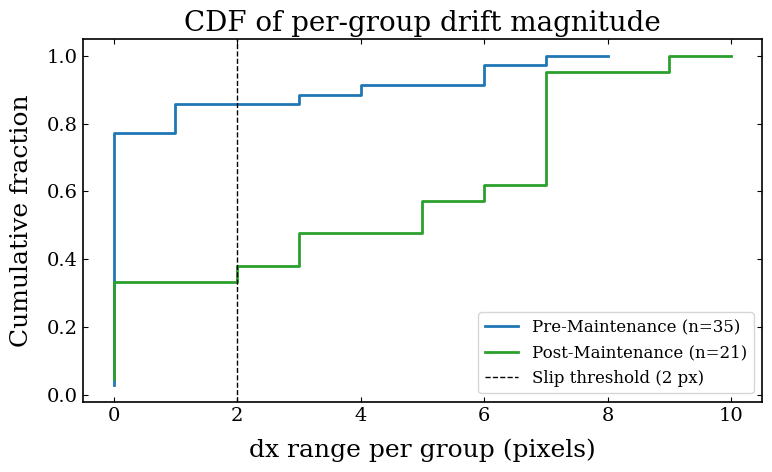

In [21]:
def get_dx_ranges(grouped_arc_files):
    ranges = []
    for g in grouped_arc_files:
        dx_clean = [
            g["dx"][i] for i in range(len(g["dx"]))
            if not np.isnan(g["dx"][i])
            and abs(g["dx"][i]) < DX_MAX
            and g["confidence_scores"][i] >= CONF_THRESHOLD
        ]
        if len(dx_clean) >= 2:
            ranges.append(max(dx_clean) - min(dx_clean))
    return np.array(ranges)

ranges_pre  = get_dx_ranges(grouped_arc_files_pre)
ranges_post = get_dx_ranges(grouped_arc_files_post)

fig, ax = plt.subplots(figsize=(8, 5))

for ranges, label, color in [(ranges_pre, "Pre-Maintenance", "C0"), (ranges_post, "Post-Maintenance", "C2")]:
    sorted_vals = np.sort(ranges)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.step(sorted_vals, cdf, label=f"{label} (n={len(ranges)})", color=color, linewidth=2)

ax.axvline(SLIP_THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"Slip threshold ({SLIP_THRESHOLD} px)")
ax.set_xlabel("dx range per group (pixels)")
ax.set_ylabel("Cumulative fraction")
ax.set_title("CDF of per-group drift magnitude")
ax.legend()
plt.tight_layout()
plt.show()

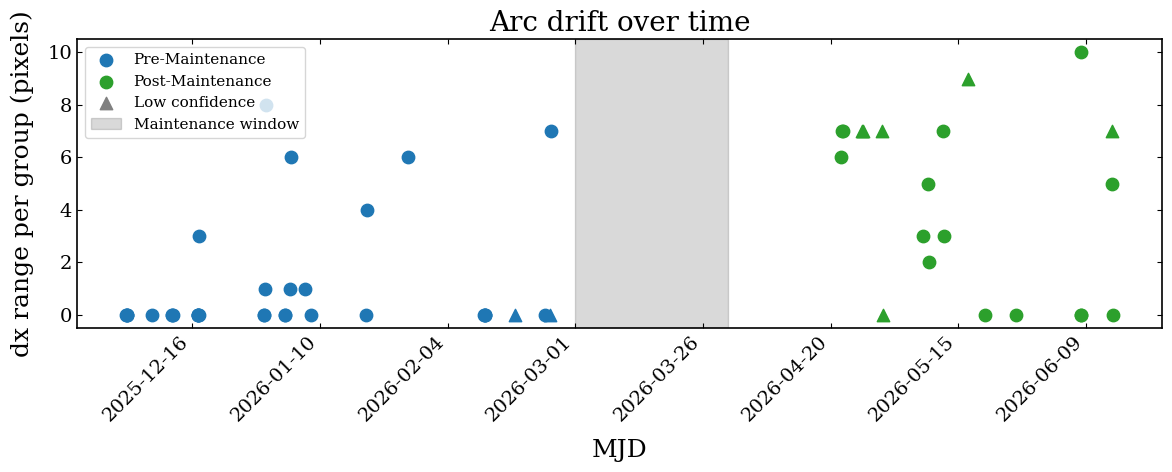

In [38]:
# CONF_THRESHOLD = 0.8
# DX_MAX         = 20
MAINT_START    = Time("2026-03-01").mjd
MAINT_END      = Time("2026-03-31").mjd

fig, ax = plt.subplots(figsize=(12, 5))

for grouped, label, color in [
    (grouped_arc_files_pre,  "Pre-Maintenance",  "C0"),
    (grouped_arc_files_post, "Post-Maintenance", "C2"),
]:
    for g in grouped:
        dx_clean = [
            g["dx"][i] for i in range(len(g["dx"]))
            if not np.isnan(g["dx"][i])
            and abs(g["dx"][i]) < DX_MAX
            and g["confidence_scores"][i] >= CONF_THRESHOLD
        ]
        if len(dx_clean) < 2:
            continue

        dx_range = max(dx_clean) - min(dx_clean)
        mid_mjd  = np.mean(Time(g["datetimes"], format="isot", scale="utc").mjd)
        min_conf = min(g["confidence_scores"][i] for i in range(len(g["dx"]))
                       if not np.isnan(g["dx"][i]) and abs(g["dx"][i]) < DX_MAX)

        marker = "o" if min_conf >= CONF_THRESHOLD else "^"
        ax.scatter(mid_mjd, dx_range, color=color, marker=marker, s=80, zorder=3)

# dummy points for legend
ax.scatter([], [], color="C0", marker="o", s=80, label="Pre-Maintenance")
ax.scatter([], [], color="C2", marker="o", s=80, label="Post-Maintenance")
ax.scatter([], [], color="gray", marker="^", s=80, label="Low confidence")

ax.axvspan(MAINT_START, MAINT_END, color="k", alpha=0.15, label="Maintenance window")
# ax.axhline(0, color="r", linestyle="--", linewidth=1, label="Zero-slip threshold")

import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from astropy.time import Time

def mjd_to_datestr(x, pos):
    try:
        return Time(x, format="mjd").strftime("%Y-%m-%d")
    except Exception:
        return ""

# ... your existing plot code ...

ax.xaxis.set_major_formatter(FuncFormatter(mjd_to_datestr))
fig.autofmt_xdate(rotation=45) 

ax.set_xlabel("MJD")
ax.set_ylabel("dx range per group (pixels)")
ax.set_title("Arc drift over time")
ax.legend(fontsize=11)
plt.tight_layout()
# plt.show()
plt.savefig("plots/arc_drift_over_time.png", dpi=150)
plt.savefig("plots/arc_drift_over_time.pdf")

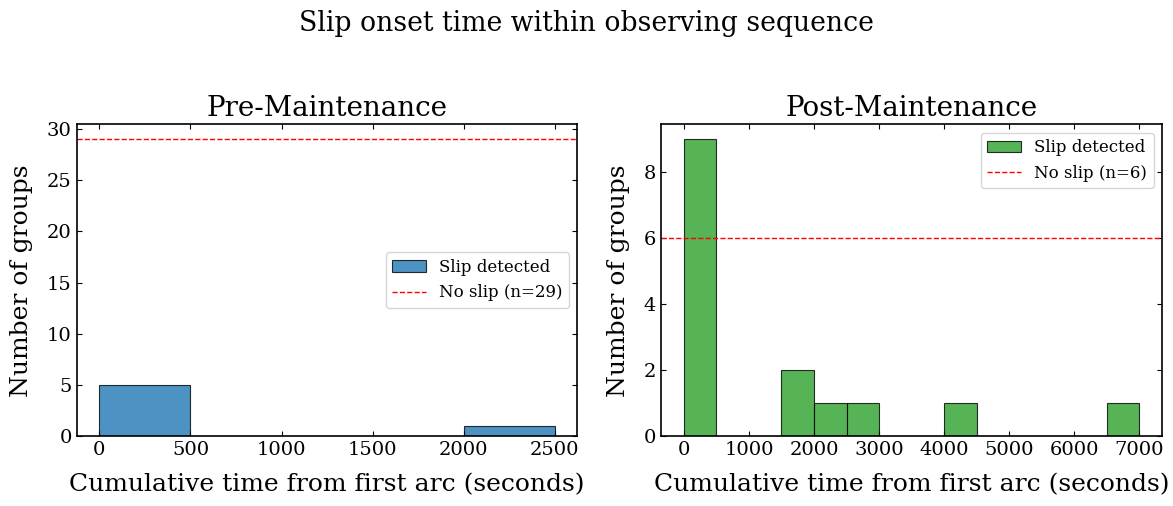

In [23]:
# CONF_THRESHOLD = 0.8
# DX_MAX         = 20
# SLIP_THRESHOLD = 2

def get_onset_times(grouped_arc_files):
    onset_times  = []
    no_slip_count = 0

    for g in grouped_arc_files:
        dx    = g["dx"]
        confs = g["confidence_scores"]
        dt    = g["delta_time_seconds"]

        dx_clean_idx = [
            i for i in range(len(dx))
            if not np.isnan(dx[i])
            and abs(dx[i]) < DX_MAX
            and confs[i] >= CONF_THRESHOLD
        ]

        if len(dx_clean_idx) < 2:
            continue

        dx_range = max(dx[i] for i in dx_clean_idx) - min(dx[i] for i in dx_clean_idx)

        if dx_range < SLIP_THRESHOLD:
            no_slip_count += 1
            continue

        # find first index where dx changes from reference (dx[0])
        ref_val = dx[dx_clean_idx[0]]
        onset_idx = next(
            (i for i in dx_clean_idx[1:] if abs(dx[i] - ref_val) >= SLIP_THRESHOLD),
            None
        )

        if onset_idx is None:
            no_slip_count += 1
            continue

        # cumulative time from file 0 to onset
        cumulative_dt = sum(dt[1:onset_idx + 1])
        onset_times.append(cumulative_dt)

    return np.array(onset_times), no_slip_count


onset_pre,  no_slip_pre  = get_onset_times(grouped_arc_files_pre)
onset_post, no_slip_post = get_onset_times(grouped_arc_files_post)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, onset_times, no_slip_count, label, color in [
    (axes[0], onset_pre,  no_slip_pre,  "Pre-Maintenance",  "C0"),
    (axes[1], onset_post, no_slip_post, "Post-Maintenance", "C2"),
]:
    bins = np.arange(0, onset_times.max() + 500, 500) if len(onset_times) > 0 else 10
    ax.hist(onset_times, bins=bins, color=color, alpha=0.8, edgecolor="k", linewidth=0.8, label="Slip detected")
    ax.axhline(no_slip_count, color="r", linestyle="--", linewidth=1, label=f"No slip (n={no_slip_count})")
    ax.set_xlabel("Cumulative time from first arc (seconds)")
    ax.set_ylabel("Number of groups")
    ax.set_title(label)
    ax.legend()

plt.suptitle("Slip onset time within observing sequence", y=1.02)
plt.tight_layout()
plt.show()

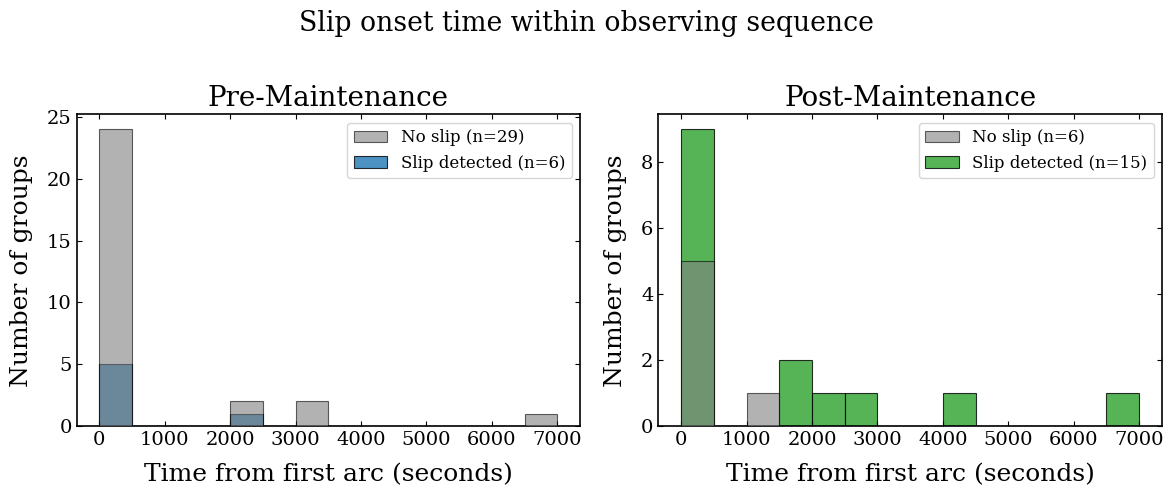

In [24]:
# CONF_THRESHOLD = 0.8
# DX_MAX         = 20
# SLIP_THRESHOLD = 2

def get_onset_and_noslip_times(grouped_arc_files):
    onset_times   = []
    noslip_times  = []

    for g in grouped_arc_files:
        dx    = g["dx"]
        confs = g["confidence_scores"]
        dt    = g["delta_time_seconds"]

        dx_clean_idx = [
            i for i in range(len(dx))
            if not np.isnan(dx[i])
            and abs(dx[i]) < DX_MAX
            and confs[i] >= CONF_THRESHOLD
        ]

        if len(dx_clean_idx) < 2:
            continue

        dx_range = max(dx[i] for i in dx_clean_idx) - min(dx[i] for i in dx_clean_idx)
        total_duration = sum(dt[1:])  # total sequence duration

        if dx_range < SLIP_THRESHOLD:
            noslip_times.append(total_duration)
            continue

        ref_val   = dx[dx_clean_idx[0]]
        onset_idx = next(
            (i for i in dx_clean_idx[1:] if abs(dx[i] - ref_val) >= SLIP_THRESHOLD),
            None
        )

        if onset_idx is None:
            noslip_times.append(total_duration)
            continue

        cumulative_dt = sum(dt[1:onset_idx + 1])
        onset_times.append(cumulative_dt)

    return np.array(onset_times), np.array(noslip_times)


onset_pre,  noslip_pre  = get_onset_and_noslip_times(grouped_arc_files_pre)
onset_post, noslip_post = get_onset_and_noslip_times(grouped_arc_files_post)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, onset_times, noslip_times, label, color in [
    (axes[0], onset_pre,  noslip_pre,  "Pre-Maintenance",  "C0"),
    (axes[1], onset_post, noslip_post, "Post-Maintenance", "C2"),
]:
    all_vals = np.concatenate([onset_times, noslip_times])
    bins     = np.arange(0, all_vals.max() + 500, 500) if len(all_vals) > 0 else 10

    ax.hist(noslip_times, bins=bins, color="gray",  alpha=0.6, edgecolor="k", linewidth=0.8, label=f"No slip (n={len(noslip_times)})", zorder=3)
    ax.hist(onset_times,  bins=bins, color=color,   alpha=0.8, edgecolor="k", linewidth=0.8, label=f"Slip detected (n={len(onset_times)})")

    ax.set_xlabel("Time from first arc (seconds)")
    ax.set_ylabel("Number of groups")
    ax.set_title(label)
    ax.legend()

plt.suptitle("Slip onset time within observing sequence", y=1)
plt.tight_layout()
# plt.show()
plt.savefig("plots/slip_onset_times_comparison.png", dpi=150)
plt.savefig("plots/slip_onset_times_comparison.pdf")

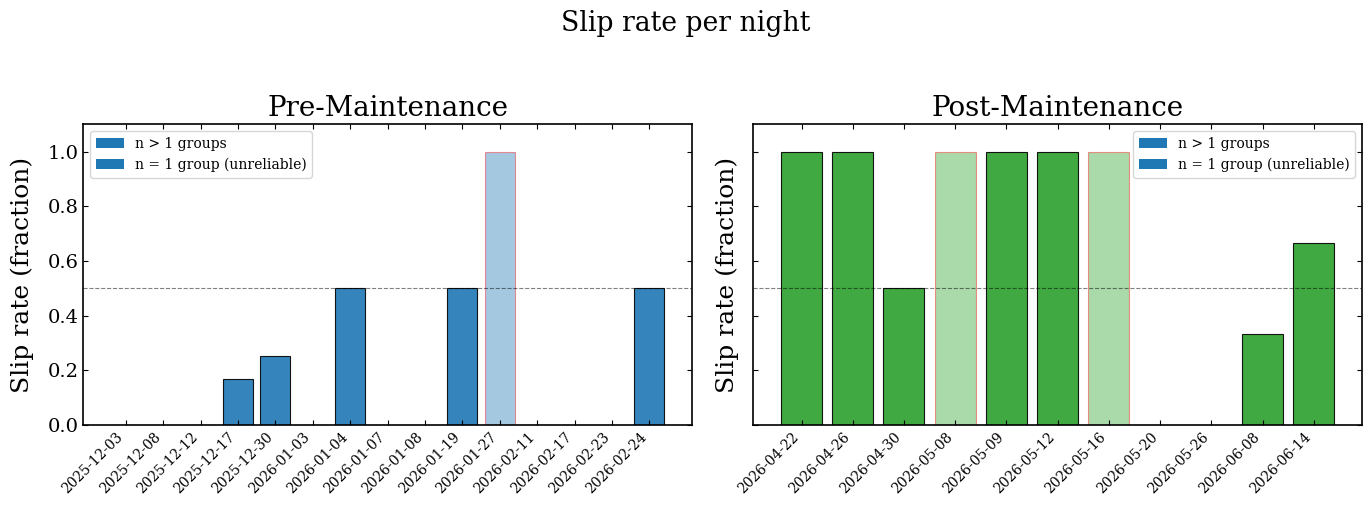

In [25]:
# CONF_THRESHOLD = 0.8
# DX_MAX         = 20
# SLIP_THRESHOLD = 2

def get_slip_rate_per_night(grouped_arc_files):
    night_data = defaultdict(lambda: {"total": 0, "slipped": 0})

    for g in grouped_arc_files:
        dx_clean = [
            g["dx"][i] for i in range(len(g["dx"]))
            if not np.isnan(g["dx"][i])
            and abs(g["dx"][i]) < DX_MAX
            and g["confidence_scores"][i] >= CONF_THRESHOLD
        ]
        if len(dx_clean) < 2:
            continue

        dx_range = max(dx_clean) - min(dx_clean)
        night_data[g["date"]]["total"]   += 1
        night_data[g["date"]]["slipped"] += 1 if dx_range >= SLIP_THRESHOLD else 0

    dates      = sorted(night_data.keys())
    rates      = [night_data[d]["slipped"] / night_data[d]["total"] for d in dates]
    totals     = [night_data[d]["total"] for d in dates]
    return dates, rates, totals


dates_pre,  rates_pre,  totals_pre  = get_slip_rate_per_night(grouped_arc_files_pre)
dates_post, rates_post, totals_post = get_slip_rate_per_night(grouped_arc_files_post)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dates, rates, totals, label, color in [
    (axes[0], dates_pre,  rates_pre,  totals_pre,  "Pre-Maintenance",  "C0"),
    (axes[1], dates_post, rates_post, totals_post, "Post-Maintenance", "C2"),
]:
    x = np.arange(len(dates))

    for i, (rate, total) in enumerate(zip(rates, totals)):
        alpha     = 0.4 if total == 1 else 0.9
        edgecolor = "red" if total == 1 else "k"
        ax.bar(x[i], rate, color=color, alpha=alpha, edgecolor=edgecolor, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Slip rate (fraction)")
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, alpha=0.5)

    # dummy bars for legend
    ax.bar([], [], color=color, alpha=0.9, edgecolor="k",   label="n > 1 groups")
    ax.bar([], [], color=color, alpha=0.4, edgecolor="red", label="n = 1 group (unreliable)")
    ax.legend(fontsize=10)

plt.suptitle("Slip rate per night", y=1.02)
plt.tight_layout()
plt.show()

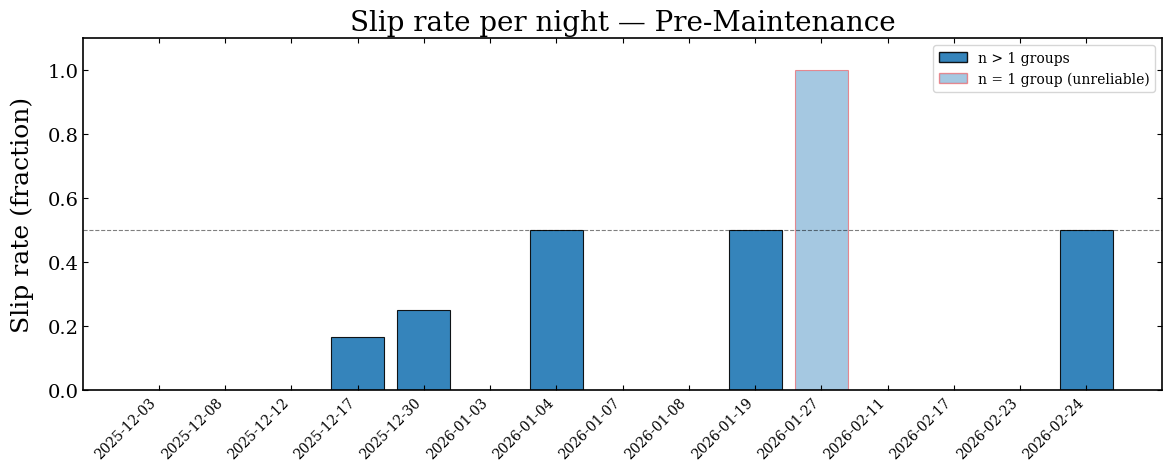

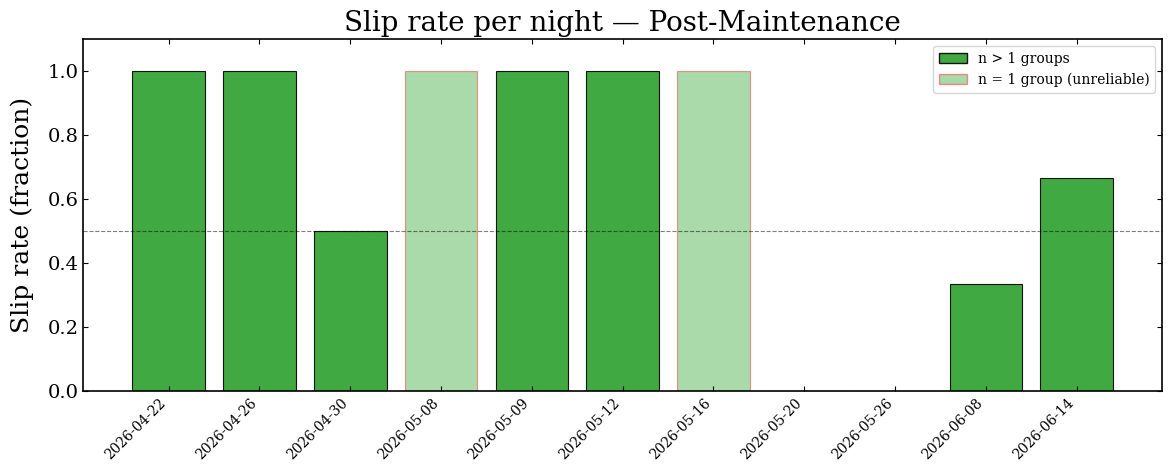

In [26]:
import matplotlib.patches as mpatches

for dates, rates, totals, label, color in [
    (dates_pre,  rates_pre,  totals_pre,  "Pre-Maintenance",  "C0"),
    (dates_post, rates_post, totals_post, "Post-Maintenance", "C2"),
]:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(dates))

    for i, (rate, total) in enumerate(zip(rates, totals)):
        alpha     = 0.4 if total == 1 else 0.9
        edgecolor = "red" if total == 1 else "k"
        ax.bar(x[i], rate, color=color, alpha=alpha, edgecolor=edgecolor, linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Slip rate (fraction)")
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Slip rate per night — {label}")
    ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, alpha=0.5)

    reliable_patch   = mpatches.Patch(facecolor=color, alpha=0.9, edgecolor="k",   label="n > 1 groups")
    unreliable_patch = mpatches.Patch(facecolor=color, alpha=0.4, edgecolor="red", label="n = 1 group (unreliable)")
    ax.legend(handles=[reliable_patch, unreliable_patch], fontsize=10)

    plt.tight_layout()
    # plt.show()
    plt.savefig(f"slip_rate_per_night_{label.replace(' ', '_').lower()}.png", dpi=300)
    plt.savefig(f"slip_rate_per_night_{label.replace(' ', '_').lower()}.pdf")

In [27]:
# CONF_THRESHOLD = 0.8
# DX_MAX         = 20
# SLIP_THRESHOLD = 2  # |dx| >= 2 counts as a slip

def arc_slip_percentage(grouped_arc_files):
    total_arcs   = 0
    slipped_arcs = 0

    for g in grouped_arc_files:
        for i in range(1, len(g["dx"])):  # skip file 0 (reference)
            dx   = g["dx"][i]
            conf = g["confidence_scores"][i]

            if np.isnan(dx) or abs(dx) >= DX_MAX or conf < CONF_THRESHOLD:
                continue

            total_arcs += 1
            if abs(dx) >= SLIP_THRESHOLD:
                slipped_arcs += 1

    pct = 100 * slipped_arcs / total_arcs if total_arcs > 0 else 0
    return total_arcs, slipped_arcs, pct


for grouped, label in [(grouped_arc_files_pre, "Pre"), (grouped_arc_files_post, "Post")]:
    total, slipped, pct = arc_slip_percentage(grouped)
    print(f"{label}-Maintenance: {slipped}/{total} arcs slipped ({pct:.1f}%)")

Pre-Maintenance: 19/65 arcs slipped (29.2%)
Post-Maintenance: 40/66 arcs slipped (60.6%)


In [28]:
def arc_slip_median(grouped_arc_files):
    slip_values = []

    for g in grouped_arc_files:
        for i in range(1, len(g["dx"])):  # skip file 0 (reference)
            dx   = g["dx"][i]
            conf = g["confidence_scores"][i]

            if np.isnan(dx) or abs(dx) >= DX_MAX or conf < CONF_THRESHOLD:
                continue

            if abs(dx) >= SLIP_THRESHOLD:
                slip_values.append(abs(dx))

    median_slip = np.median(slip_values) if slip_values else 0
    return median_slip, len(slip_values)


for grouped, label in [(grouped_arc_files_pre, "Pre"), (grouped_arc_files_post, "Post")]:
    median_slip, n = arc_slip_median(grouped)
    print(f"{label}-Maintenance: median |dx| of slipped arcs = {median_slip:.1f} px (n={n})")

Pre-Maintenance: median |dx| of slipped arcs = 6.0 px (n=19)
Post-Maintenance: median |dx| of slipped arcs = 7.0 px (n=40)


In [29]:
from scipy.signal import find_peaks

def plot_arc_overlay(group, zoom_width=60):
    """
    Plots all arc spectra in a group overlaid, with a zoom-in panel on the strongest peak.

    Inputs:
        group: dict from grouped_arc_files_pre/post
        zoom_width: total width of zoom window in pixels (default 60)
    """
    files = [
        os.path.join(group["file_paths"][i], group["arc_files"][i])
        for i in range(len(group["arc_files"]))
    ]

    spectra = []
    for f in files:
        _, data = read_fits_file(f)
        spec = np.sum(data[1], axis=0).astype(np.float64)
        spectra.append(spec)

    # find strongest peak in reference spectrum (file 0)
    ref_spec = spectra[0]
    peaks, props = find_peaks(ref_spec[:1000], height=0)
    strongest_idx = peaks[np.argmax(props["peak_heights"])]

    half = zoom_width // 2
    x_zoom_min = max(0, strongest_idx - half)
    x_zoom_max = min(len(ref_spec), strongest_idx + half)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # ---- full spectrum panel ----
    colors = plt.cm.viridis(np.linspace(0, 1, len(spectra)))
    for i, spec in enumerate(spectra):
        dx_label = group["dx"][i] if i < len(group["dx"]) else "?"
        axes[0].plot(spec, color=colors[i], alpha=0.8, linewidth=1,
                     label=f"file {i} (dx={dx_label})")

    axes[0].axvspan(x_zoom_min, x_zoom_max, color="red", alpha=0.15, label="Zoom region")
    axes[0].set_xlabel("Pixel")
    axes[0].set_ylabel("Counts")
    axes[0].set_title(f"{group['object']} — {group['date']} — {group['grating']} (full spectrum)")
    axes[0].legend(fontsize=9, ncol=2)

    # ---- zoom panel ----
    for i, spec in enumerate(spectra):
        dx_label = group["dx"][i] if i < len(group["dx"]) else "?"
        axes[1].plot(spec, color=colors[i], alpha=0.85, linewidth=1.5,
                     label=f"file {i} (dx={dx_label})")

    axes[1].set_xlim(x_zoom_min, x_zoom_max)
    axes[1].axvline(strongest_idx, color="k", linestyle=":", linewidth=0.8, alpha=0.5, label="Reference peak")
    axes[1].set_xlabel("Pixel")
    axes[1].set_ylabel("Counts")
    axes[1].set_title(f"Zoom on strongest peak (pixel {strongest_idx})")
    axes[1].legend(fontsize=9, ncol=2)

    plt.tight_layout()
    plt.show()


# usage — pick by target name and date
def find_group(grouped_arc_files, object_name, date):
    for g in grouped_arc_files:
        if g["object"] == object_name and g["date"] == date:
            return g
    return None

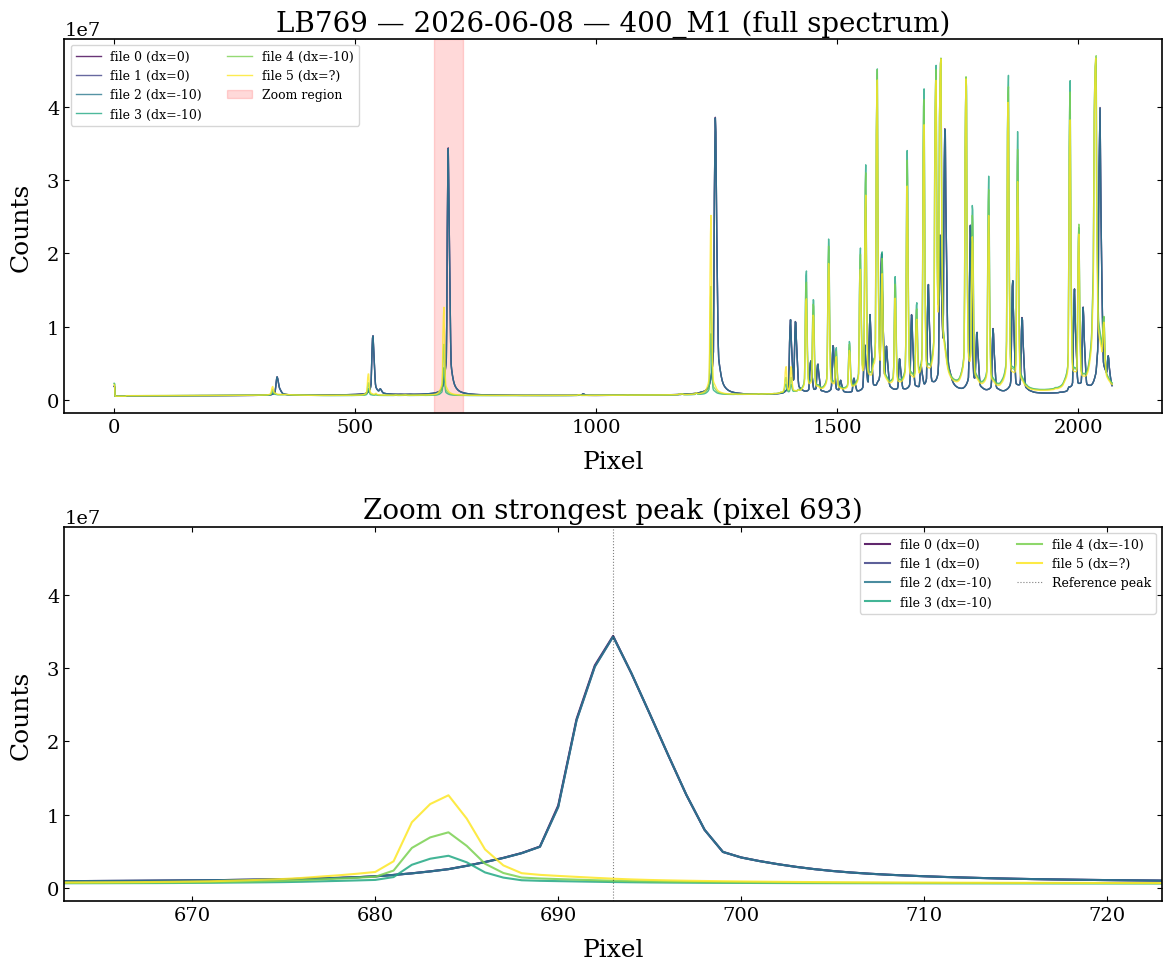

In [41]:
# example
# source, date = "HD60753", "2026-06-07"
# source, date = "ZTF26aaonmha", "2026-04-22"
# source, date = "LTT9239", "2026-06-06"
source, date = "LB769", "2026-06-08"

group = find_group(grouped_arc_files_post, source, date) #  "ZTF26aaonmha", "2026-04-22
if group:
    plot_arc_overlay(group)
else:
    print("Group not found")